In [1]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Ambil hanya kolom yang dibutuhkan
x = df["bmi"].values
y = df["charges"].values

print("Jumlah data:", len(x))
print("Contoh BMI:", x[:5])
print("Contoh Charges:", y[:5])

Jumlah data: 1338
Contoh BMI: [27.9   33.77  33.    22.705 28.88 ]
Contoh Charges: [16884.924    1725.5523   4449.462   21984.47061  3866.8552 ]


In [4]:
x_mean = x.mean()
x_std = x.std()

y_mean = y.mean()
y_std = y.std()

x_norm = (x - x_mean) / x_std
y_norm = (y - y_mean) / y_std

print("x mean:", x_mean)
print("x std :", x_std)
print("y mean:", y_mean)
print("y std :", y_std)

x mean: 30.66339686098655
x std : 6.0959076415894256
y mean: 13270.422265141257
y std : 12105.484975561612


In [5]:
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 100
loss_history = []

In [6]:
n = len(x_norm)

for epoch in range(epochs):
    total_loss = 0

    for i in range(n):
        xi = x_norm[i]
        yi = y_norm[i]

        # Forward
        y_pred = w * xi + b

        # Error
        error = y_pred - yi

        # Loss per data
        loss = error ** 2
        total_loss += loss

        # Gradient
        dw = 2 * error * xi
        db = 2 * error

        # Update parameter
        w = w - learning_rate * dw
        b = b - learning_rate * db

    avg_loss = total_loss / n
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.6f}, w: {w:.6f}, b: {b:.6f}")

Epoch 10, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 20, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 30, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 40, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 50, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 60, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 70, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 80, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 90, Loss: 0.986291, w: 0.114873, b: 0.050741
Epoch 100, Loss: 0.986291, w: 0.114873, b: 0.050741


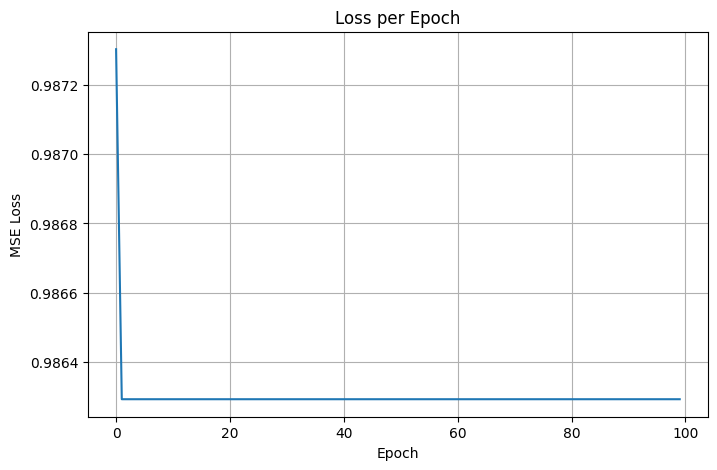

In [7]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()